<a href="https://colab.research.google.com/github/marsxarts/Credit-Card-Customer-Data/blob/main/Cleaned_Customer_Segmentation_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation with K-Means Clustering
This project analyzes credit card customer behavior to uncover patterns and segment users based on engagement habits. Using clustering and PCA visualization, we extract actionable business insights.

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
sns.set(style='whitegrid')

In [4]:
# 2. Load Dataset
df = pd.read_csv('Credit Card Customer Data.csv')
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [5]:
# 3. Initial Data Inspection
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,330.500000,55141.443939,34574.242424,4.706061,2.403030,2.606061,3.583333
std,190.669872,25627.772200,37625.487804,2.167835,1.631813,2.935724,2.865317
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,165.750000,33825.250000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,330.500000,53874.500000,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,495.250000,77202.500000,48000.000000,6.000000,4.000000,4.000000,5.000000
max,660.000000,99843.000000,200000.000000,10.000000,5.000000,15.000000,10.000000


In [12]:
df.drop(['Sl_No', 'Customer Key'], axis=1, inplace=True)

In [13]:
# 5. Select Relevant Features for Clustering
features = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']
df_cluster = df[features]

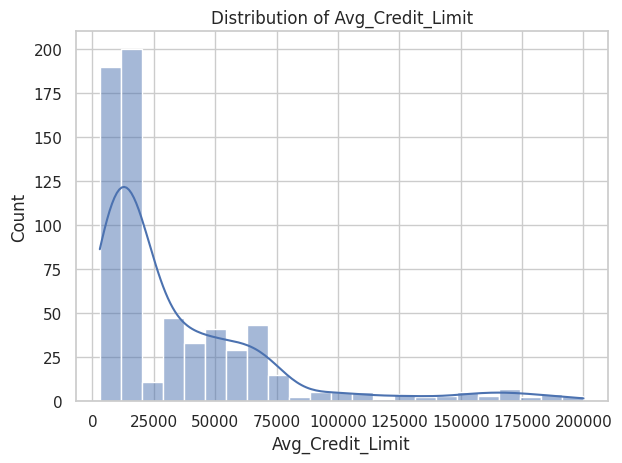

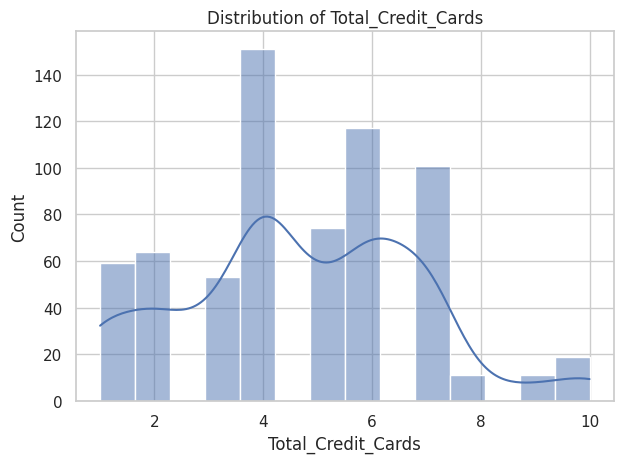

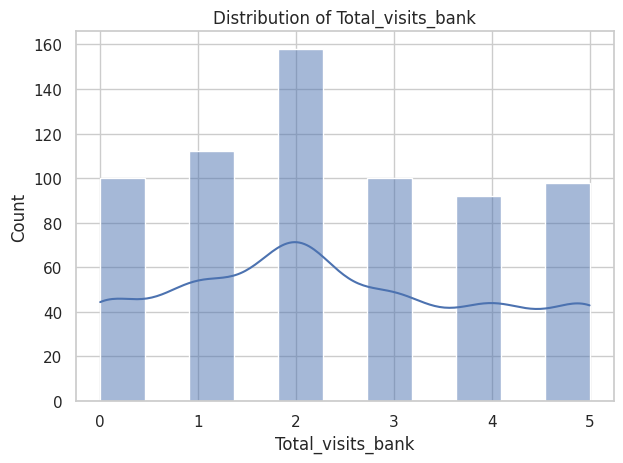

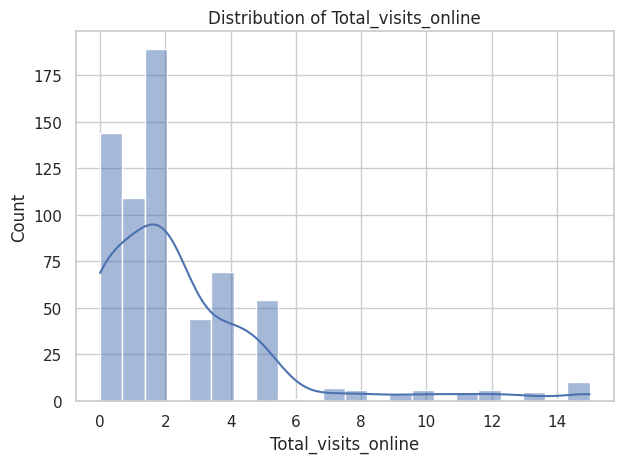

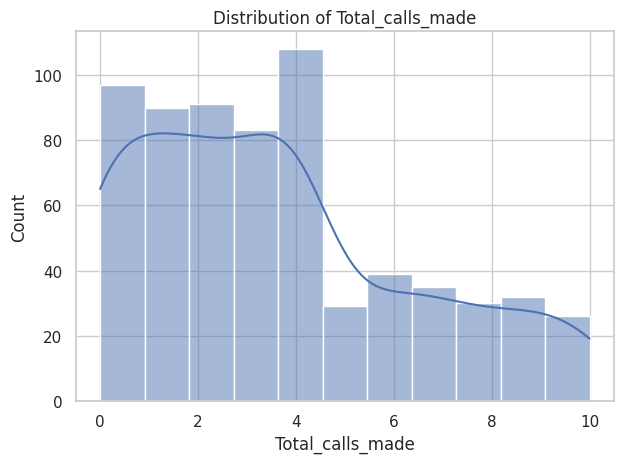

In [14]:
# 6. Visualize Distributions
for col in features:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

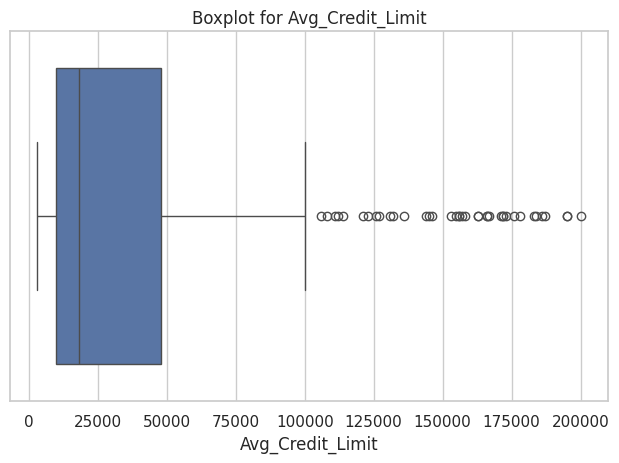

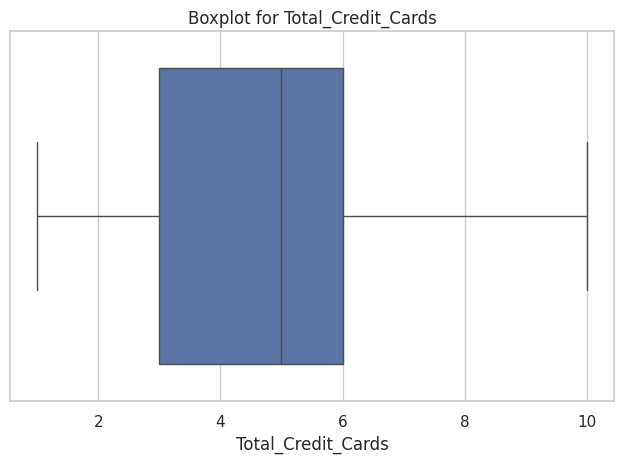

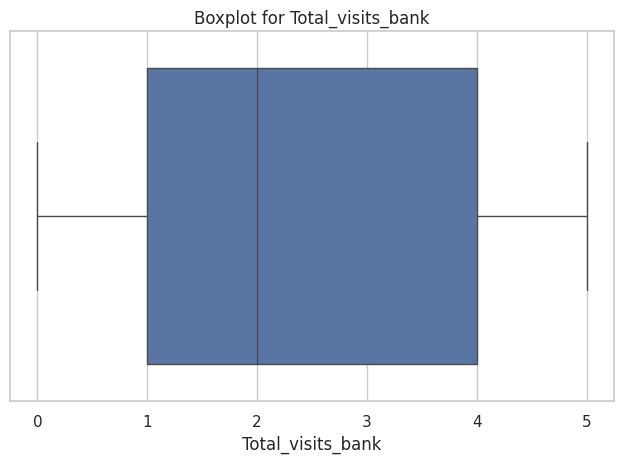

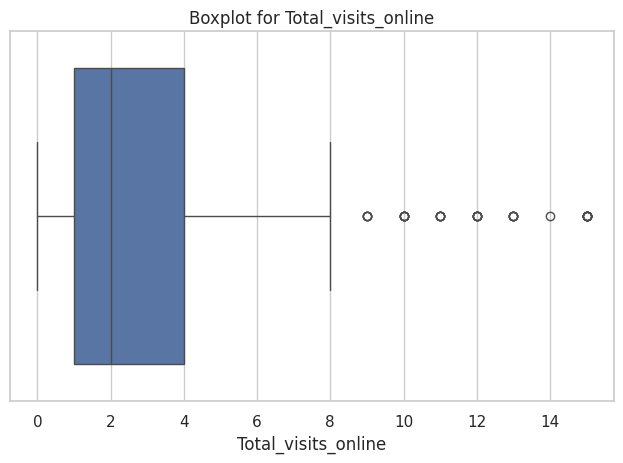

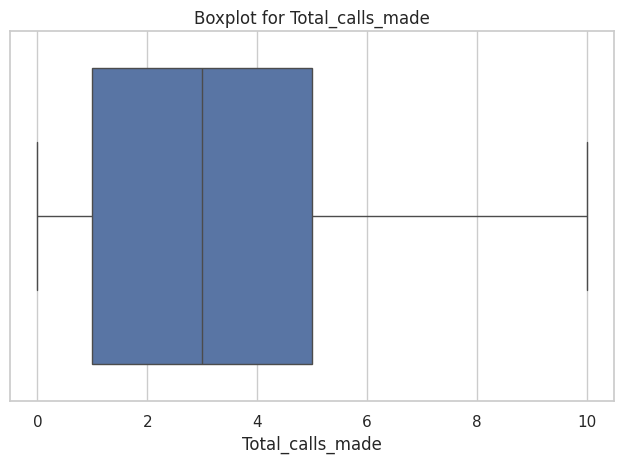

In [15]:
# 7. Boxplots for Outlier Detection
for col in features:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot for {col}')
    plt.tight_layout()
    plt.show()

### Why Clustering?
Clustering allows us to group users based on behavioral data — revealing hidden patterns that support personalization, marketing, and customer retention.

In [16]:
# 8. Standardize Features
scaler = StandardScaler()
scaled = scaler.fit_transform(df_cluster)

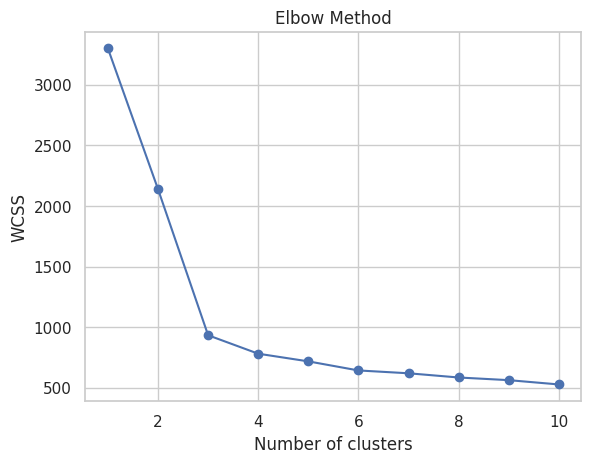

In [17]:
# 9. Elbow Method to Find Optimal k
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [18]:
# 10. Fit KMeans with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled)

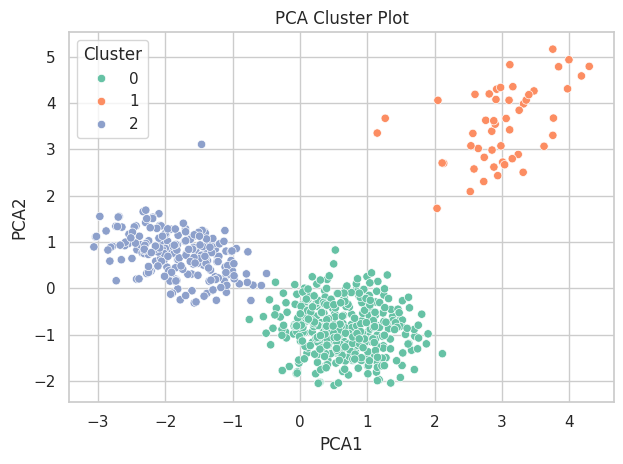

In [19]:
# 11. PCA for Visualization
pca = PCA(n_components=2)
components = pca.fit_transform(scaled)
df['PCA1'] = components[:, 0]
df['PCA2'] = components[:, 1]
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('PCA Cluster Plot')
plt.tight_layout()
plt.show()

### Cluster Insights
- **Cluster 0**: Dormant Users – Low engagement across all channels
- **Cluster 1**: Digital Enthusiasts – High online usage and credit activity
- **Cluster 2**: Support-Reliant – High call volume, less digital engagement

In [20]:
# 12. Cluster Group Summary
df.groupby('Cluster')[features].mean()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,33782.383420,5.515544,3.489637,0.981865,2.000000
1,141040.000000,8.740000,0.600000,10.900000,1.080000
2,12174.107143,2.410714,0.933036,3.553571,6.870536


### Final Recommendations
- **Re-engage Dormant Users** with personalized incentives
- **Upsell Digital Enthusiasts** through rewards or premium products
- **Digitally migrate Support-Reliant Users** with guided tools and training

These recommendations support increased customer lifetime value and cost-efficient service delivery.